In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

# Load and prepare data

df = pd.read_csv('../data/Phishing_Email.csv')
print(f"Original dataset shape: {df.shape}")

print(df.head() )       # Voir les 5 premières lignes
print(df.shape )        # Nombre de lignes et colonnes
print(df.columns )      # Noms des colonnes
print(df.info() )       # Types + valeurs manquantes

print(df.isna().sum())
print(df.duplicated().sum())

Original dataset shape: (18650, 3)
   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  
(18650, 3)
Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB

Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Percentage distribution:
Email Type
Safe Email        60.71
Phishing Email    39.29
Name: count, dtype: float64
Nombre d'emails vides : 19


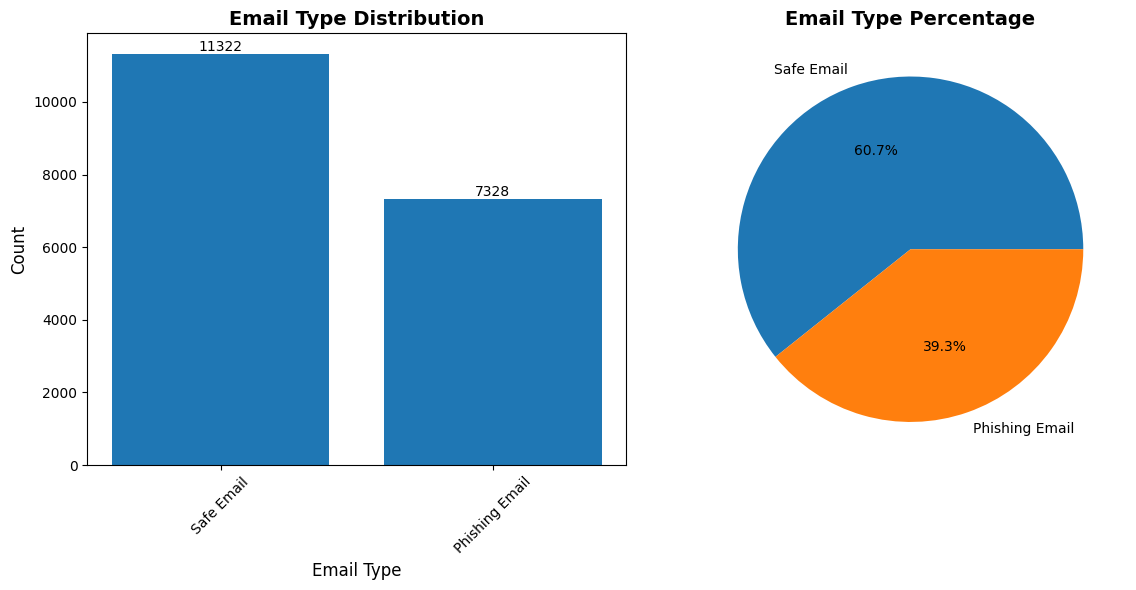

In [ ]:
type_distribution = df['Email Type'].value_counts()
print(type_distribution)
print(f"\nPercentage distribution:")
print((type_distribution / len(df) * 100).round(2))

empty_emails = df[
    df["Email Text"].isna() |
    (df["Email Text"].str.strip() == "") 
    
]

print("Nombre d'emails vides :", empty_emails.shape[0])

# Visualize the distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(type_distribution.index, type_distribution.values)
plt.title('Email Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Email Type', fontsize=12)
plt.ylabel('nombre', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(type_distribution.values, labels=type_distribution.index, autopct='%1.1f%%')
plt.title('Email Type Pourcentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

df = df.dropna().reset_index(drop=True)
df['label'] = df['Email Type'].apply(lambda x: 1 if 'phishing' in str(x).lower() else 0)
print(f"\ndistribution Class :")
print(df['label'].value_counts())
print(f"\nPourcentage: {df['label'].value_counts(normalize=True) * 100}")


Class distribution:
label
0    11322
1     7312
Name: count, dtype: int64

Percentage: label
0    60.759901
1    39.240099
Name: proportion, dtype: float64


In [89]:
# Filtrer les emails phishing
phishing_df = df[df["Email Type"] == "Phishing Email"]
df["Email Type"].value_counts()
# Nettoyer le texte
text = phishing_df["Email Text"].dropna().astype(str).str.lower()

# Compter les mots fréquents
# Fusionner tous les emails
all_text = " ".join(text)

# Extraire seulement les mots
words = re.findall(r'\b[a-z]+\b', all_text)

# Supprimer mots inutiles
filtered_words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]

# Compter
word_counts = Counter(filtered_words)

# Top 20 mots
print(word_counts.most_common(20))

[('com', 6140), ('email', 5353), ('http', 4930), ('free', 4512), ('mail', 3952), ('money', 3929), ('company', 3899), ('information', 3881), ('business', 3606), ('time', 3375), ('report', 3130), ('click', 3111), ('www', 3088), ('new', 3085), ('just', 2809), ('order', 2755), ('make', 2749), ('people', 2515), ('address', 2468), ('list', 2444)]


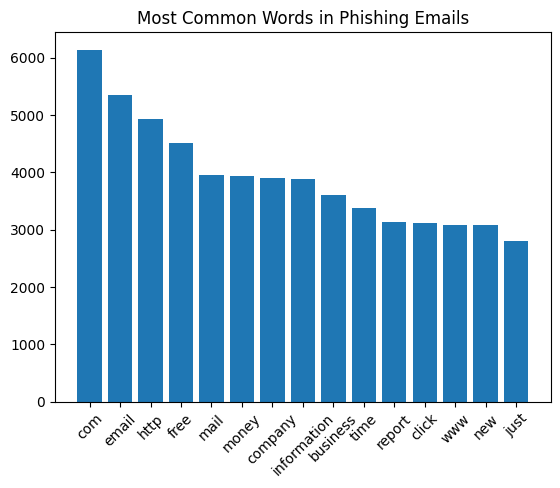

In [ ]:
# Visualisation
common_words = word_counts.most_common(15)
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Mots les plus fréquents dans les e-mails de phishing")
plt.show()

['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '11'
 '12' '13' '14' '15' '16' '17' '18' '19' '1994' '1995' '1997' '1998'
 '1999' '20' '200' '2000' '2001' '2002' '2004' '2005' '21' '22' '23' '24'
 '25' '26' '27' '28' '29' '30' '300' '31' '32' '34' '35' '39' '3d' '40'
 '44' '45' '49' '50' '500' '55' '60' '70' '713' '75' '80' '800' '90' '95'
 '97' '98' '99' '_______________________________________________'
 'ability' 'able' 'abstract' 'abstracts' 'ac' 'academic' 'accept'
 'acceptance' 'accepted' 'access' 'according' 'account' 'acquisition'
 'act' 'action' 'actual' 'actually' 'ad' 'add' 'added' 'addition'
 'additional' 'address' 'addresses' 'adobe' 'advanced' 'advertising'
 'advice' 'affiliation' 'ago' 'agreement' 'al' 'allow' 'america'
 'american' 'analysis' 'announcement' 'annual' 'answer' 'aol'
 'application' 'applications' 'applied' 'apply' 'approach' 'approaches'
 'appropriate' 'april' 'area' 'areas' 'article' 'ask' 'asked' 'aspects'
 'assets' 'association' 'attac

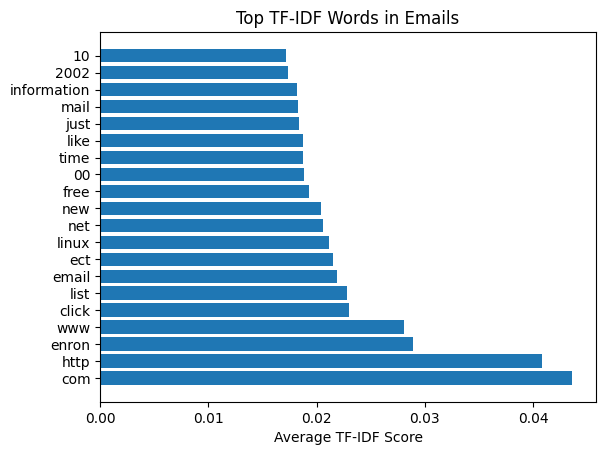

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

X = vectorizer.fit_transform(df["Email Text"].astype(str))

feature_names = vectorizer.get_feature_names_out()
print(feature_names)

mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
top_indices = mean_tfidf.argsort()[-20:][::-1]

top_words = [feature_names[i] for i in top_indices]
top_scores = mean_tfidf[top_indices]
plt.figure()
plt.barh(top_words, top_scores)
plt.title("Principaux mots TF-IDF dans les e-mails")
plt.xlabel("Moyenne TF-IDF Score")
plt.show()

[('statements', 2004), ('save', 1426), ('adobe', 983), ('removed', 929), ('advice', 713), ('pills', 678), ('stocks', 641), ('viagra', 613), ('oo', 560), ('grants', 553), ('guaranteed', 535), ('mailings', 490), ('mails', 464), ('sightings', 459), ('investing', 456), ('br', 446), ('mortgage', 445), ('td', 412), ('risks', 403), ('prescription', 397)]


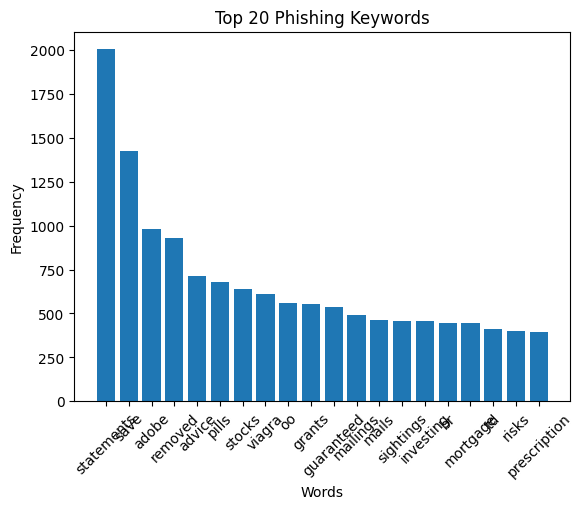

In [ ]:
phishing_df = df[df["Email Type"] == "Phishing Email"]
legit_df = df[df["Email Type"] == "Safe Email"]

def get_word_counts(text_series):
    text = " ".join(text_series.dropna().astype(str).str.lower())
    words = re.findall(r'\b[a-z]+\b', text)
    return Counter(words)

phishing_counts = get_word_counts(phishing_df["Email Text"])
legit_counts = get_word_counts(legit_df["Email Text"])

phishing_keywords = {}

for word, count in phishing_counts.items():
    legit_count = legit_counts.get(word, 0)
    
    if count > 20 and count > legit_count * 2:
        phishing_keywords[word] = count

# Top 20 phishing keywords
top_keywords = sorted(phishing_keywords.items(), key=lambda x: x[1], reverse=True)[:20]

print(top_keywords)

# Visualisation
# Separate words and counts
words = [item[0] for item in top_keywords]
counts = [item[1] for item in top_keywords]

# Create bar chart
plt.figure()
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top 20 Phishing mot-clé")
plt.xlabel("Mots")
plt.ylabel("frequence")

plt.show()

In [93]:
keywords_only = [keyword for keyword, count in top_keywords]

with open("top_keywords.txt", "w", encoding="utf-8") as f:
    for keyword in keywords_only:
        f.write(keyword + "\n")

In [94]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, keyword_file="top_keywords.txt"):
        self.keyword_file = keyword_file
        self.phishing_keywords = self._load_keywords()
    
    def _load_keywords(self):
        try:
            with open(self.keyword_file, "r", encoding="utf-8") as f:
                keywords = [line.strip() for line in f if line.strip()]
            return keywords
        except FileNotFoundError:
            print("Keyword file not found.")
            return []
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X_processed = X.copy()
        if isinstance(X, pd.Series):
            X_processed = X_processed.apply(self._clean_text)
        return X_processed
    
    def _clean_text(self, text):
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = str(text).lower()
        
        # Remove URLs
        text = re.sub(r'https?://\S+|www\.\S+', ' [URL] ', text)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', ' [EMAIL] ', text)
        
        # Remove phone numbers
        text = re.sub(r'[\+\d\-\s\(\)]{10,}', ' [PHONE] ', text)
        
        # Remove special characters but keep basic punctuation for context
        text = re.sub(r'[^\w\s\.\,\!\?\:\;\$\%]', ' ', text)
        
        # Replace numbers
        text = re.sub(r'\d+', ' [NUMBER] ', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def extract_features(self, text):
        """Extract numerical features from text"""
        features = {}
        text_lower = text.lower()
        
        # Keyword counts
        features['keyword_count'] = sum(1 for keyword in self.phishing_keywords 
                                       if keyword in text_lower)
        
        # Text statistics
        features['text_length'] = len(text)
        features['word_count'] = len(text.split())
        features['avg_word_length'] = np.mean([len(w) for w in text.split()]) if text.split() else 0
        
        # Special pattern counts
        features['url_count'] = len(re.findall(r'\[URL\]', text))
        features['email_count'] = len(re.findall(r'\[EMAIL\]', text))
        features['exclamation_count'] = text.count('!')
        features['question_count'] = text.count('?')
        features['dollar_count'] = text.count('$') + text.count('£') + text.count('€')
        
        return features
 

In [95]:
preprocessor = TextPreprocessor()
df['processed_text'] = preprocessor.transform(df['Email Text'])
with open("processed_text.txt", "w", encoding="utf-8") as f:
    for text in df['processed_text']:
        f.write(text + "\n")
print(df['processed_text'])

0        re : [NUMBER] . [NUMBER] , disc : uniformitari...
1        the other side of galicismos galicismo is a sp...
2        re : equistar deal tickets are you still avail...
3        hello i am your hot lil horny toy. i am the on...
4        software at incredibly low prices [NUMBER] % l...
                               ...                        
18629    date a lonely housewife always wanted to date ...
18630    request submitted : access request for anita ....
18631    re : important prc mtg hi dorn john , as you d...
18632    press clippings letter on californian utilitie...
18633                                                empty
Name: processed_text, Length: 18634, dtype: object


In [96]:
numerical_features = []
for text in df['processed_text']:
    features = preprocessor.extract_features(text)
    numerical_features.append(features)

df_numerical = pd.DataFrame(numerical_features)
df_numerical.to_csv("numero.csv", index=False, encoding="utf-8")
df_combined = pd.concat([df, df_numerical], axis=1)
df_combined.to_csv("data_for_use.csv", index=False, encoding="utf-8")
print(df_combined)

       Unnamed: 0                                         Email Text  \
0               0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1               1  the other side of * galicismos * * galicismo *...   
2               2  re : equistar deal tickets are you still avail...   
3               3  \nHello I am your hot lil horny toy.\n    I am...   
4               4  software at incredibly low prices ( 86 % lower...   
...           ...                                                ...   
18629       18646  date a lonely housewife always wanted to date ...   
18630       18647  request submitted : access request for anita ....   
18631       18648  re : important - prc mtg hi dorn & john , as y...   
18632       18649  press clippings - letter on californian utilit...   
18633       18650                                              empty   

           Email Type  label  \
0          Safe Email      0   
1          Safe Email      0   
2          Safe Email      0   
3      

In [97]:
X = df_combined[['processed_text'] + list(df_numerical.columns)]
y = df_combined['label']




print('X:',X)
print('\n')
print('Y:',y)

X:                                           processed_text  keyword_count  \
0      re : [NUMBER] . [NUMBER] , disc : uniformitari...              1   
1      the other side of galicismos galicismo is a sp...              0   
2      re : equistar deal tickets are you still avail...              1   
3      hello i am your hot lil horny toy. i am the on...              1   
4      software at incredibly low prices [NUMBER] % l...              3   
...                                                  ...            ...   
18629  date a lonely housewife always wanted to date ...              0   
18630  request submitted : access request for anita ....              0   
18631  re : important prc mtg hi dorn john , as you d...              1   
18632  press clippings letter on californian utilitie...              0   
18633                                              empty              0   

       text_length  word_count  avg_word_length  url_count  email_count  \
0              990   